In [ ]:
!pip install ucimlrepo
!pip install streamlit

## DATA INSPECTION

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd

# fetch dataset
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

# data (as pandas dataframes)
X = cdc_diabetes_health_indicators.data.features
y = cdc_diabetes_health_indicators.data.targets

df= pd.concat([X, y], axis=1)
# variable information
#print in tabular fashion
display(cdc_diabetes_health_indicators.variables)
print(cdc_diabetes_health_indicators.variables)

In [ ]:
print("Sample of features (X):")
print(X.head())

print("\nSample of targets (y):")
print(y.head())

In [ ]:
# Descriptive statistics
df.describe()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("\nDistribusi Kelas Target (%):")
print(df['Diabetes_binary'].value_counts(normalize=True)*100)

plt.figure(figsize=(6, 4))
sns.countplot(x=y['Diabetes_binary'])
plt.title('Distribution of Diabetes_binary (Target Class)')
plt.xlabel('Diabetes_binary')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No Diabetes', 'Diabetes'])
plt.show()

# PRE-PROCESSING DATA

## DATA CLEANING

In [ ]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

In [ ]:
# Remove duplicates
df = df.drop_duplicates()
#print rows after removal of duplicates
print("Number of rows after removing duplicates:", len(df))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to check for outliers with boxplots
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i) # Arrange plots in a 2x3 grid
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# EXPLORATORY DATA ANALYSIS (EDA)

## Univariate Analysis

Menggunakan histogram dan box plot untuk melihat distribusi fitur numerik serta visualisasi count plot untuk melihat distribusi fitur kategorik

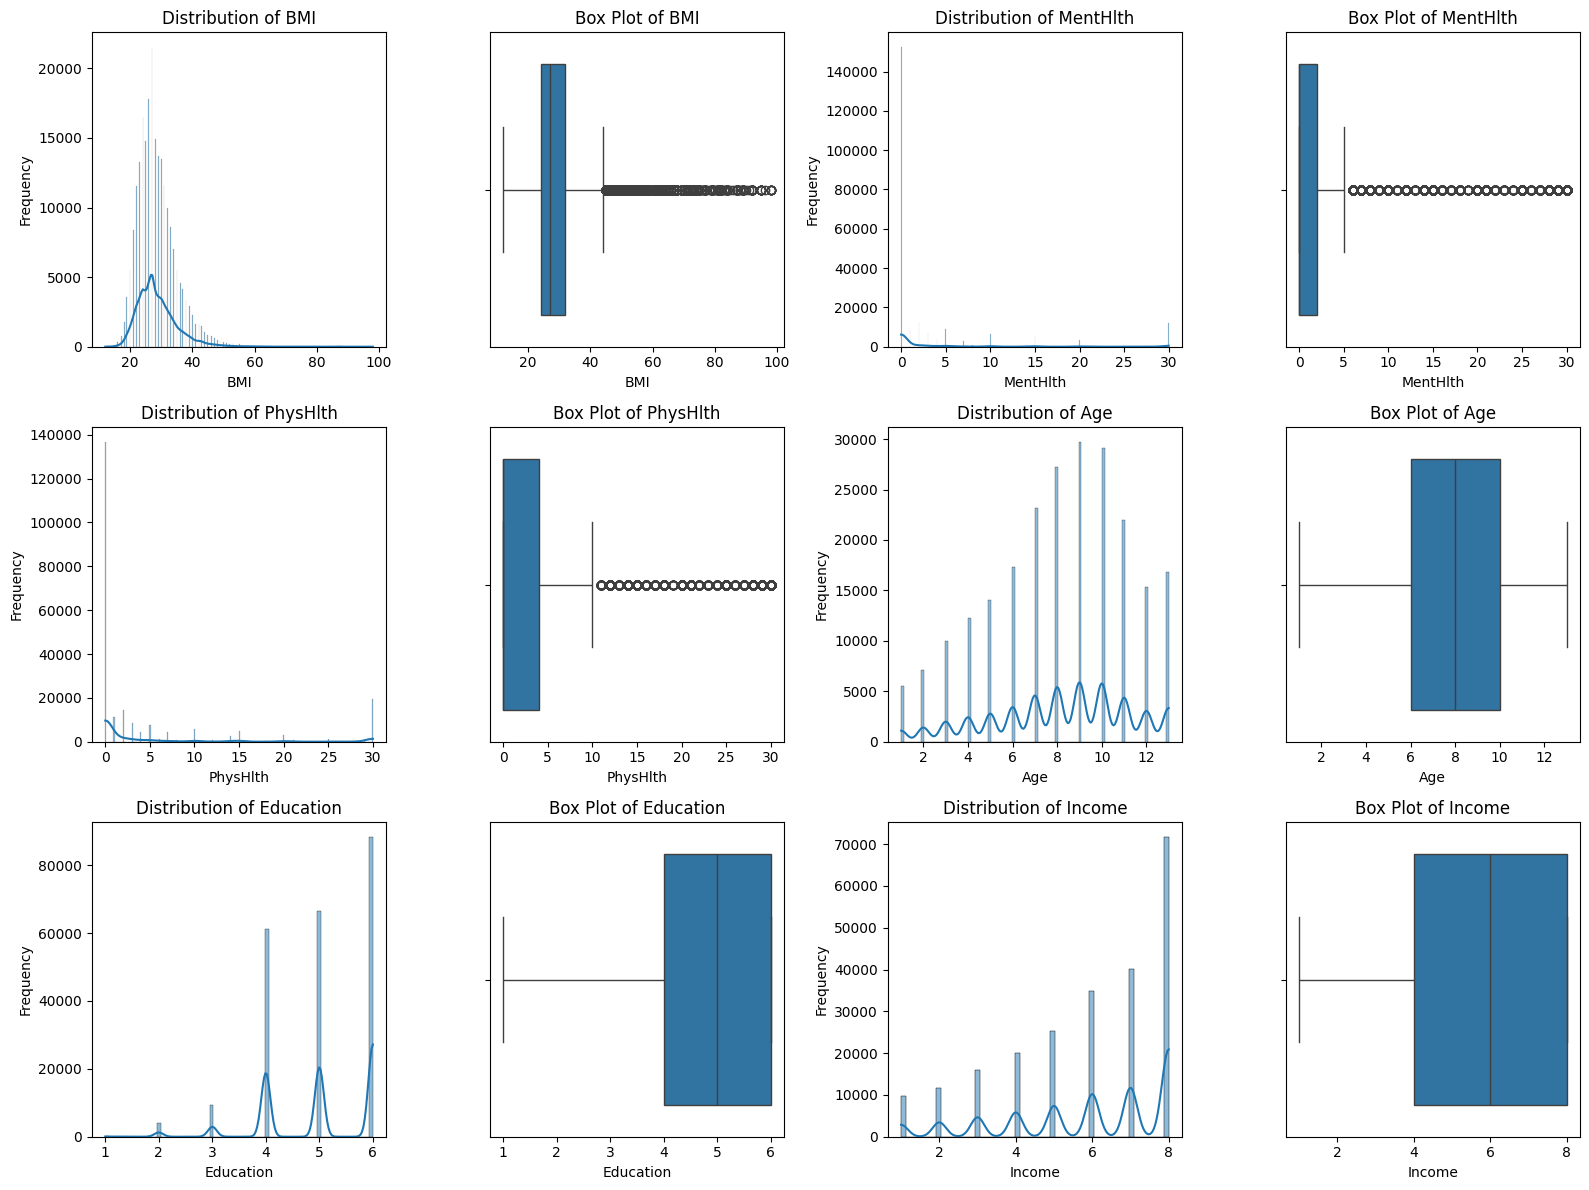

In [53]:
#exploratory data analysis
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']

# Determine the number of rows and columns for subplots
n_cols = 4
n_rows = (len(numerical_cols) * 2 + n_cols - 1) // n_cols # Two plots per column (hist and box)

# Histograms and Box plots for numerical columns side by side
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4)) # Adjusted figure size

axes = axes.flatten() # Flatten the axes array for easy iteration

for i, col in enumerate(numerical_cols):
    # Plot histogram
    sns.histplot(data=df, x=col, kde=True, ax=axes[i*2])
    axes[i*2].set_title(f'Distribution of {col}')
    axes[i*2].set_xlabel(col)
    axes[i*2].set_ylabel('Frequency')

    # Plot box plot
    sns.boxplot(data=df, x=col, ax=axes[i*2+1])
    axes[i*2+1].set_title(f'Box Plot of {col}')
    axes[i*2+1].set_xlabel(col)


# Hide any unused subplots
for j in range(len(numerical_cols) * 2, len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

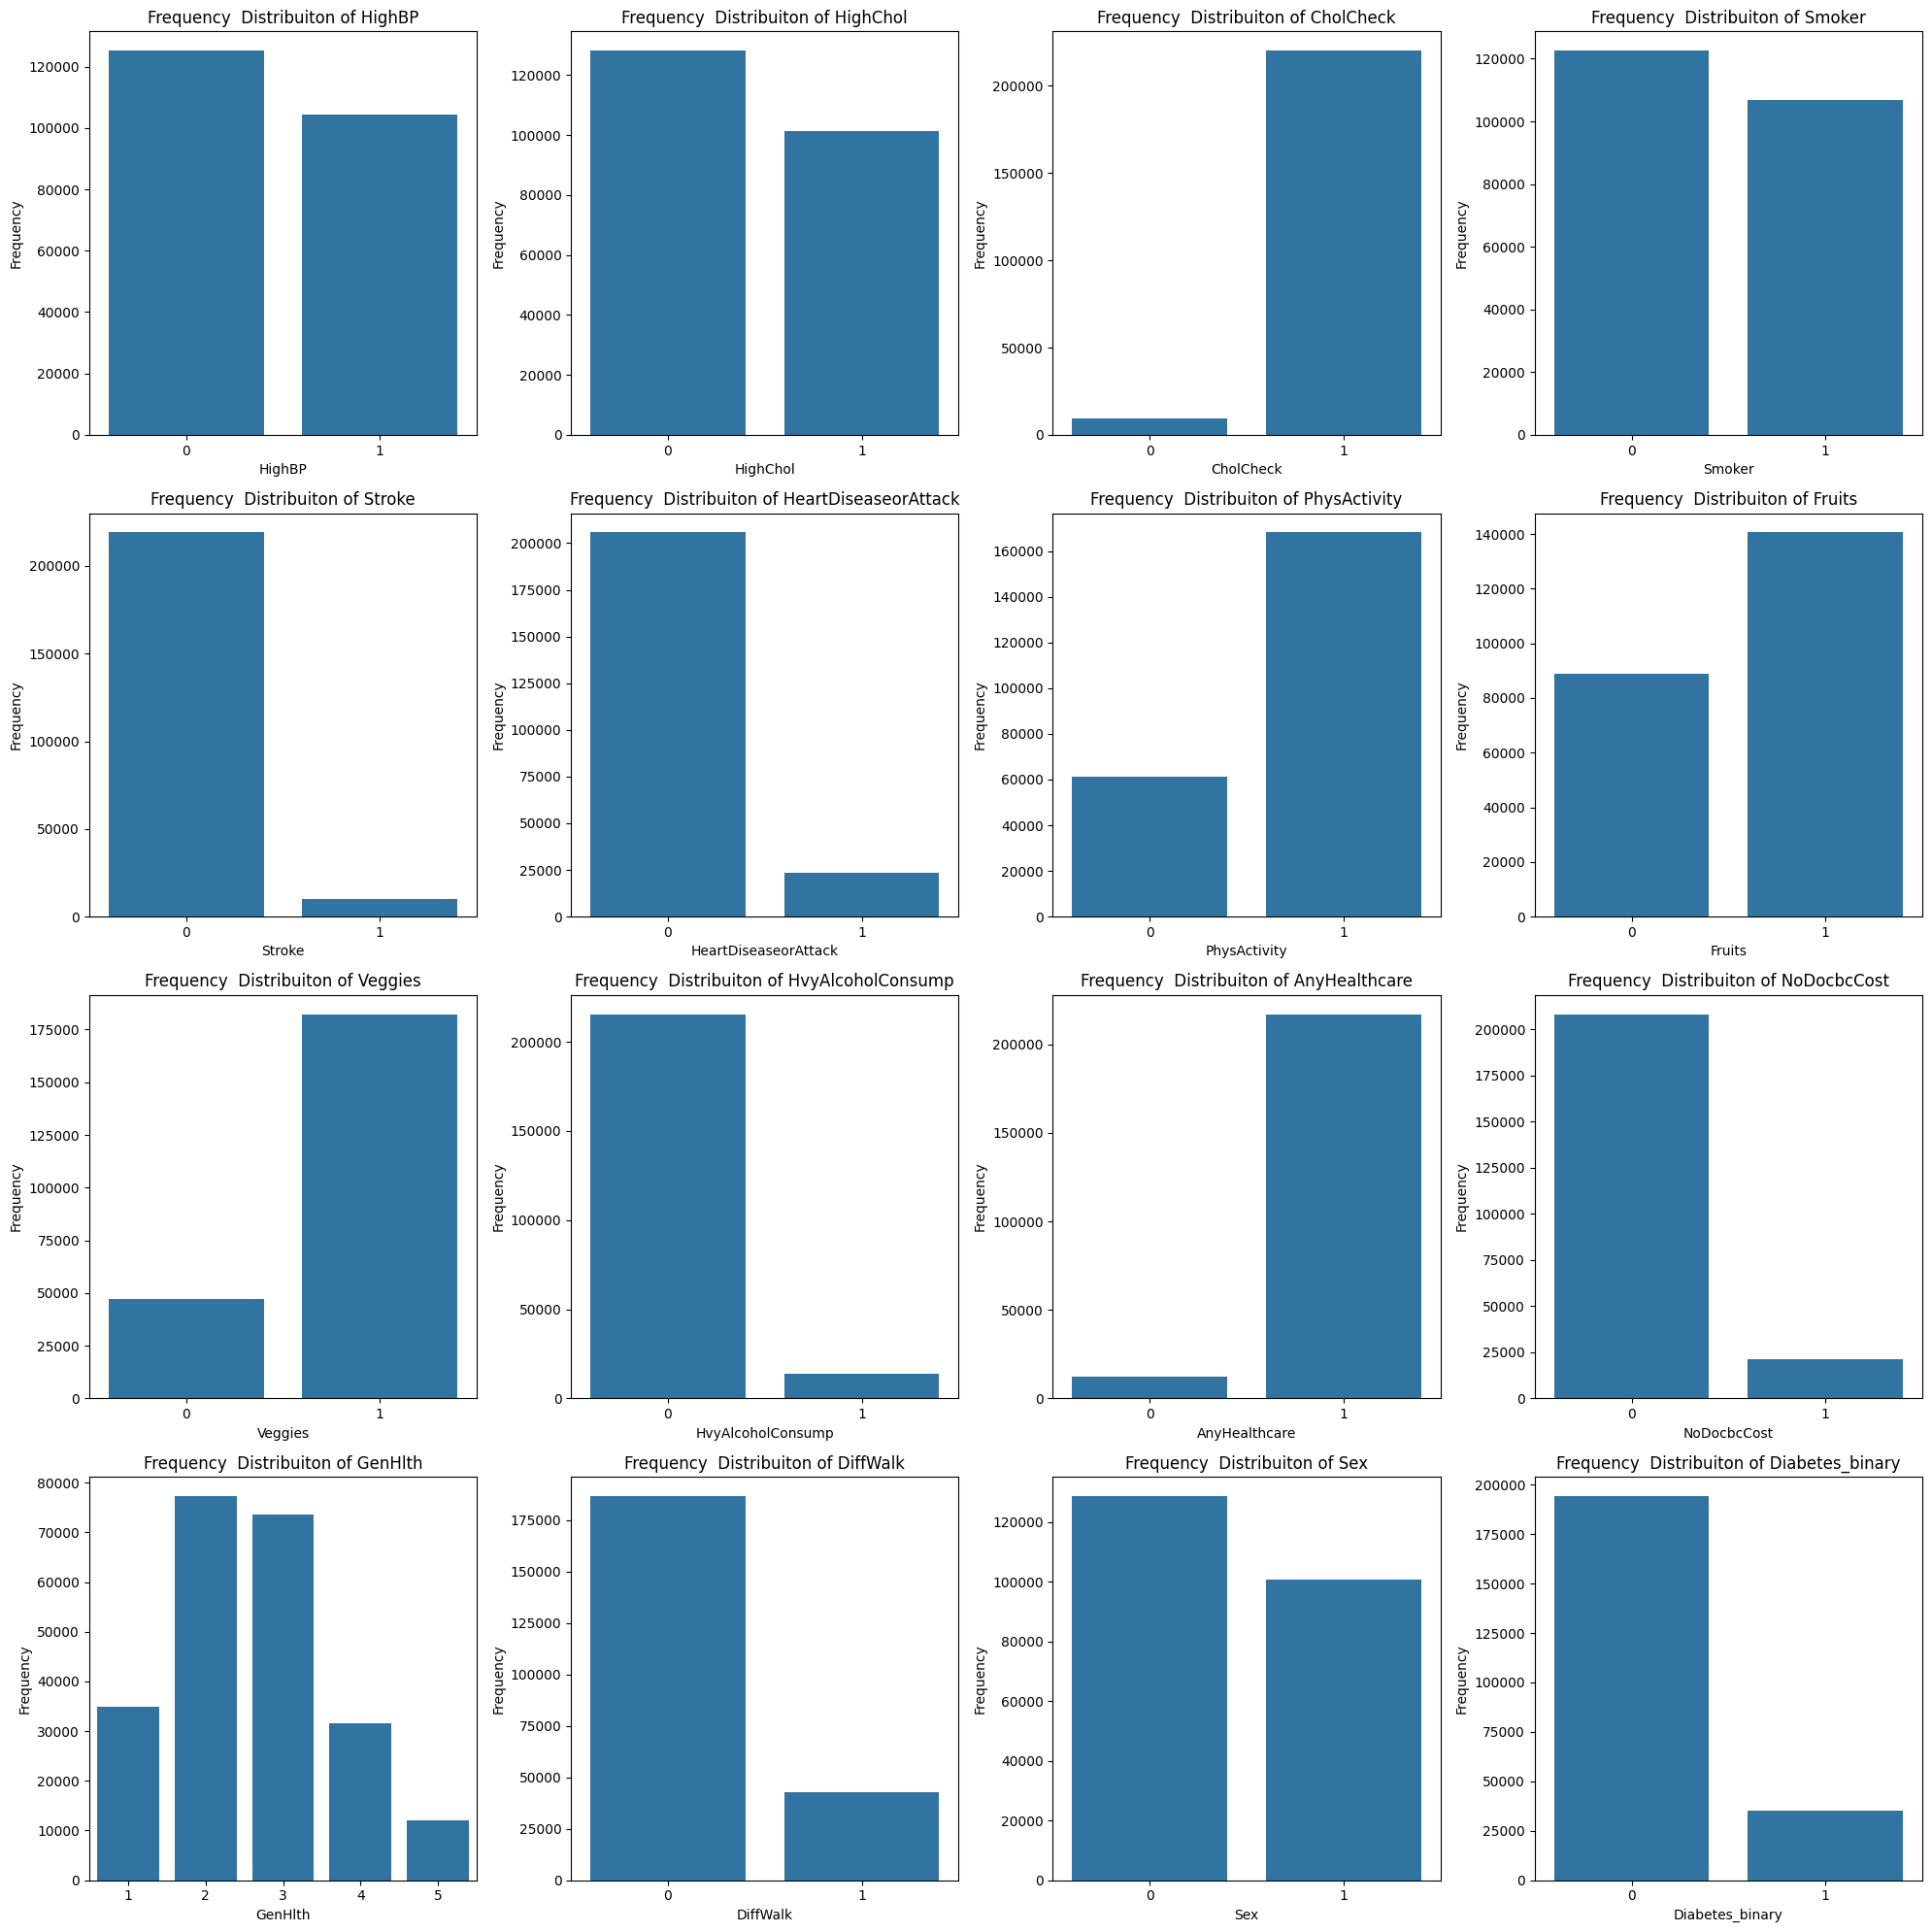

In [54]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex','Diabetes_binary']

# Count plots for categorical columns with reduced size in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i])
    axes[i].set_title(f'Frequency  Distribuiton of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Hide any unused subplots
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Bivariate Analysis

Melihat distribusi fitur numerik terhadap masing-masing kelas pada fitur target. Visualisasi bertujuan untuk melihat bagaimana pengaruh setiap fitur terhadap pasien diabetes dan non diabetes.

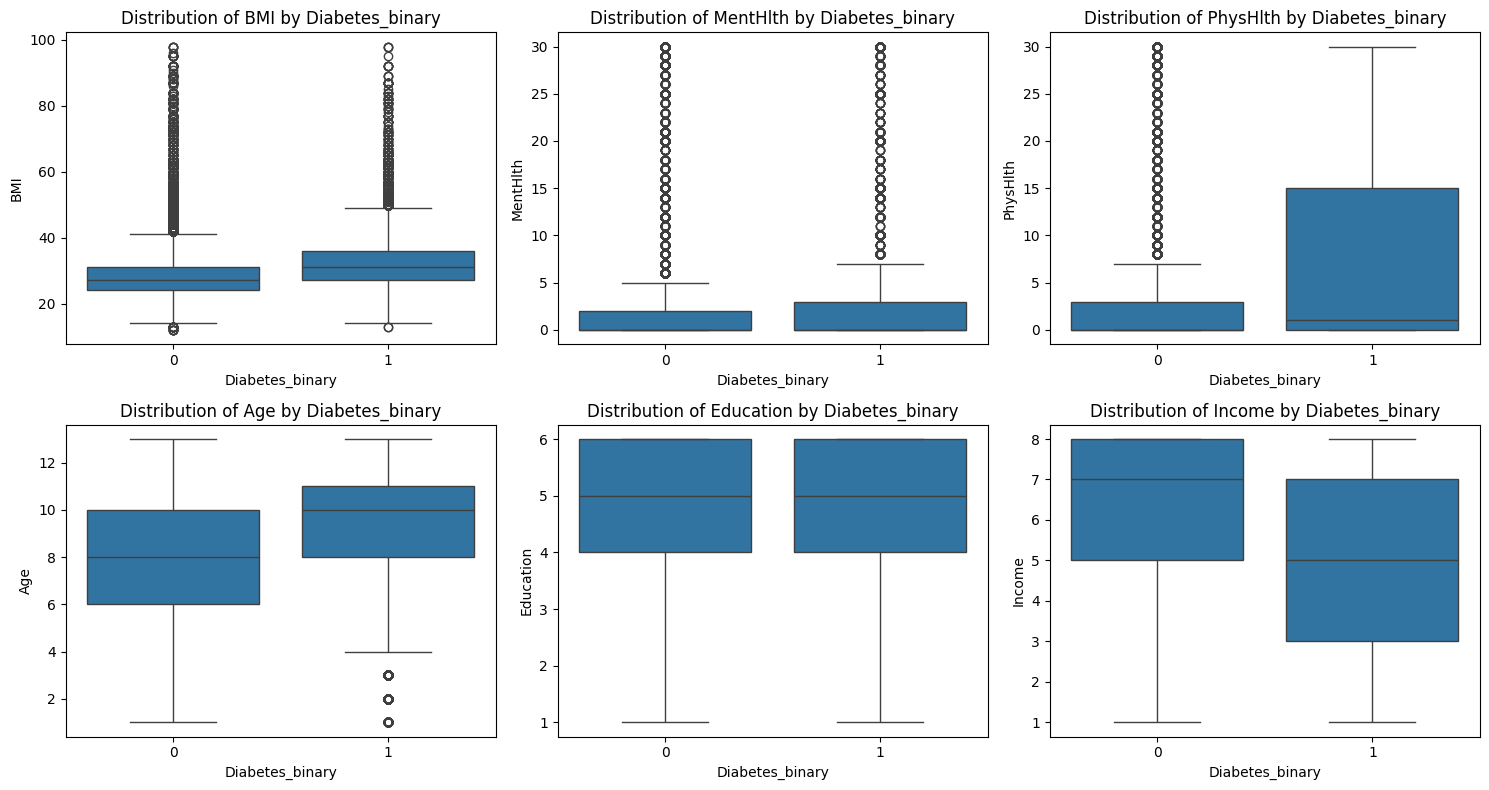

In [55]:
numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']


# Box plots for numerical columns by Diabetes_binary
fig, axes = plt.subplots(2, 3, figsize=(15, 8)) # Adjusted to 2 rows and 3 columns for 6 plots
axes = axes.flatten() # Flatten the 2x3 array of axes to easily iterate

for i, col in enumerate(numerical_cols):
    sns.boxplot(data=df, x='Diabetes_binary', y=col, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Diabetes_binary')
    axes[i].set_xlabel('Diabetes_binary')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


Berdasarkan analisis boxplot, BMI dan PhysicalHealth menunjukkan perbedaan distribusi yang cukup jelas antara kelompok diabetes dan non-diabetes, sehingga keduanya berpotensi menjadi variabel prediktor yang baik dalam klasifikasi diabetes.

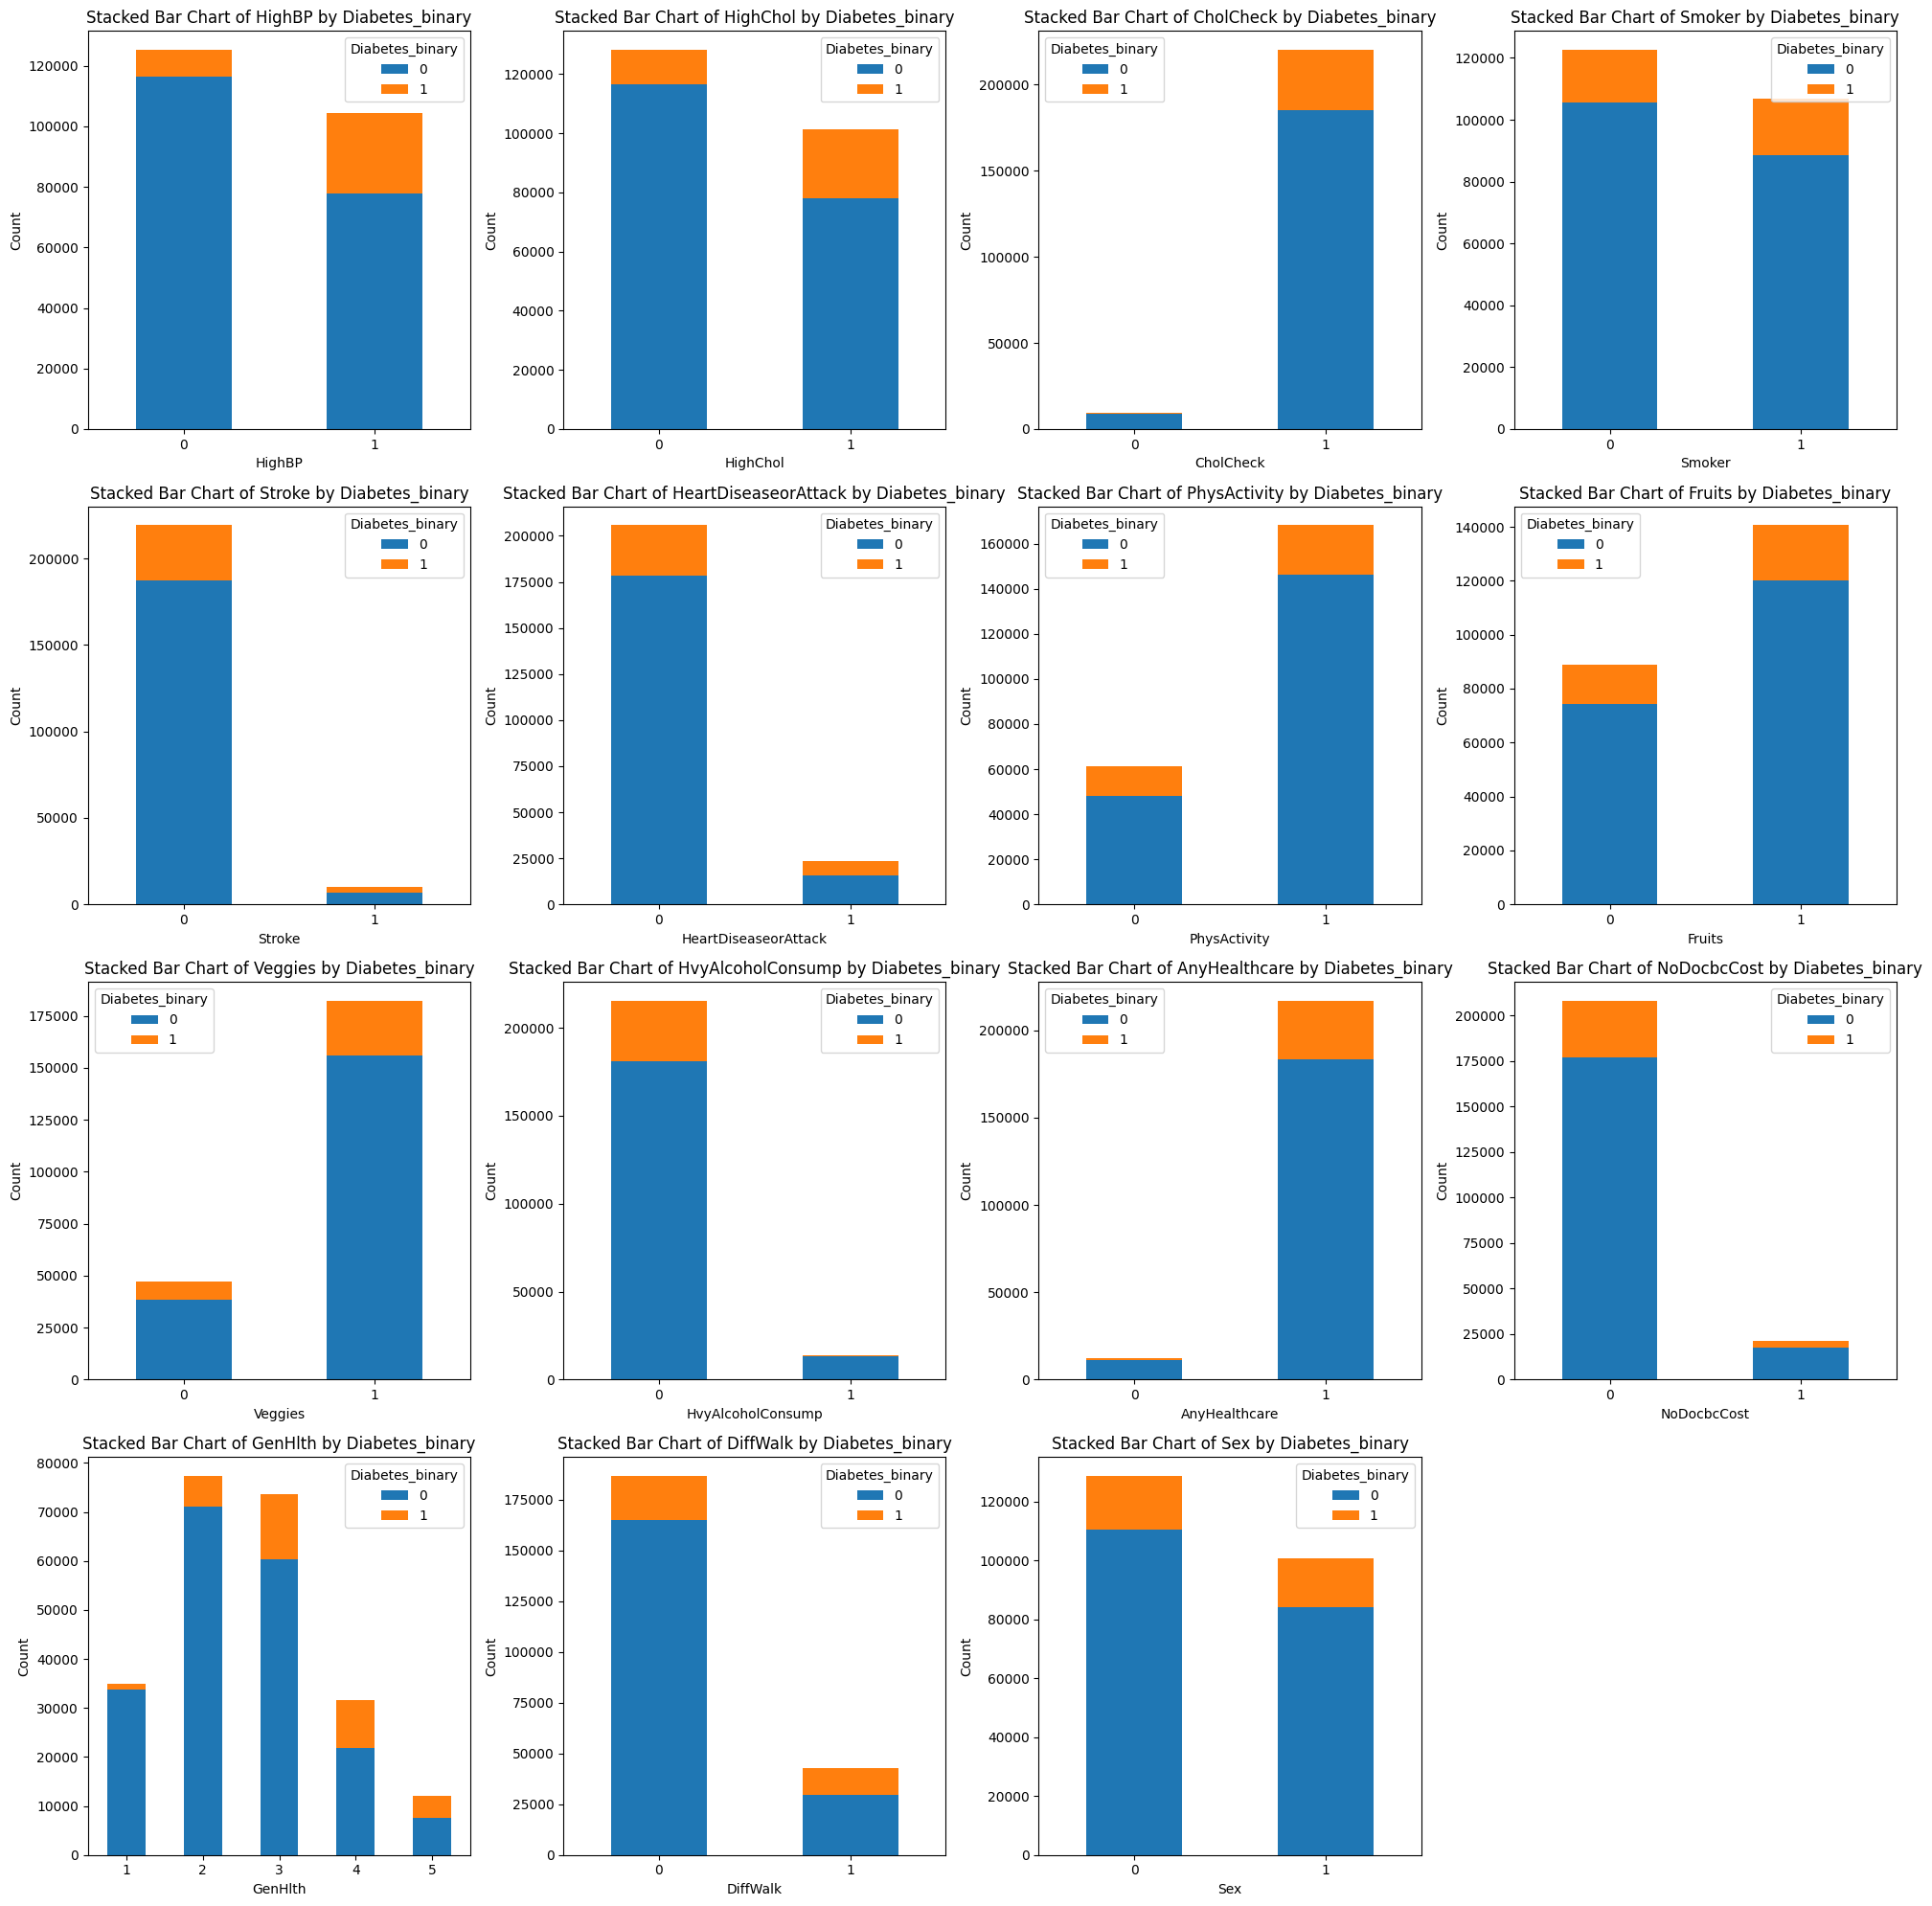

In [56]:
categorical_cols = ['HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
                     'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare',
                     'NoDocbcCost', 'GenHlth', 'DiffWalk', 'Sex'] # Removed 'Diabetes_binary' from categorical_cols


# Count plots for categorical columns by Diabetes_binary in a 4x4 grid
fig, axes = plt.subplots(4, 4, figsize=(20, 20)) # Changed to 4x4 grid for 16 plots
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    # Create a crosstab for stacked bar chart
    crosstab = pd.crosstab(df[col], df['Diabetes_binary'])
    crosstab.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'Stacked Bar Chart of {col} by Diabetes_binary')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0) # Rotate x-axis labels if needed


# Hide any unused subplots (although with 15 plots and 16 axes, there will be one unused)
for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Berdasarkan analisis stacked bar chart, variabel HighBP, HighChol, CholCheck, PhysActivity, dan AnyHealthcare menunjukkan adanya asosiasi dengan variabel Diabetes_binary. Oleh karena itu, variabel-variabel tersebut berpotensi menjadi prediktor yang berguna dalam memprediksi status diabetes.

visualisasi pair plot untuk melihat hubungan antar fitur numerik

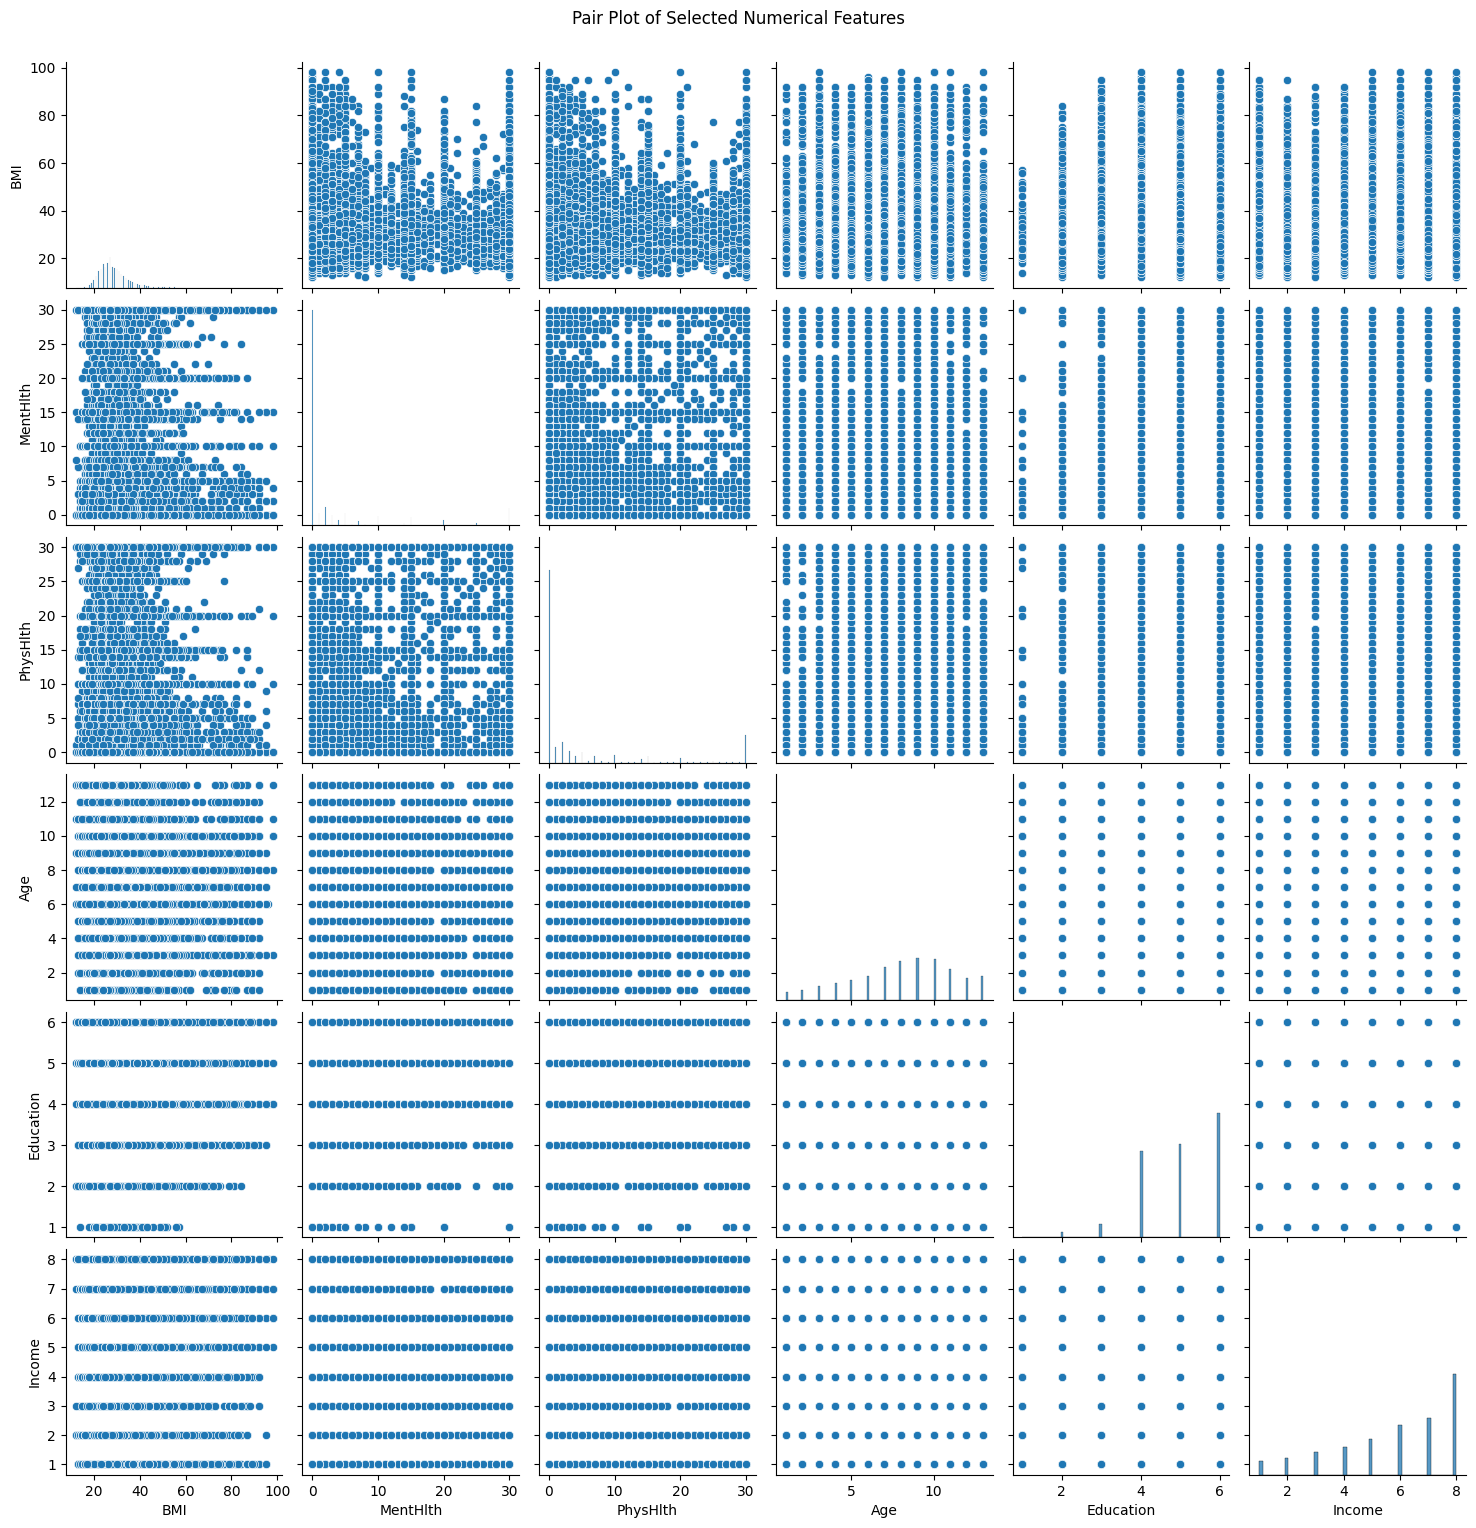

In [57]:
# Generate pair plots for a subset of numerical columns to visualize pairwise relationships
subset_numerical_cols = ['BMI', 'MentHlth', 'PhysHlth', 'Age', 'Education', 'Income']
sns.pairplot(df[subset_numerical_cols])
plt.suptitle('Pair Plot of Selected Numerical Features', y=1.02)
plt.show()

Berdasarkan analisis pair plot, tidak terdapat hubungan linear yang kuat antara BMI, MentHlth, PhysHlth, Age, Education, dan Income. Titik-titik data tersebar secara acak dan tidak membentuk pola garis naik atau turun yang jelas.

**Correlation Analysis**

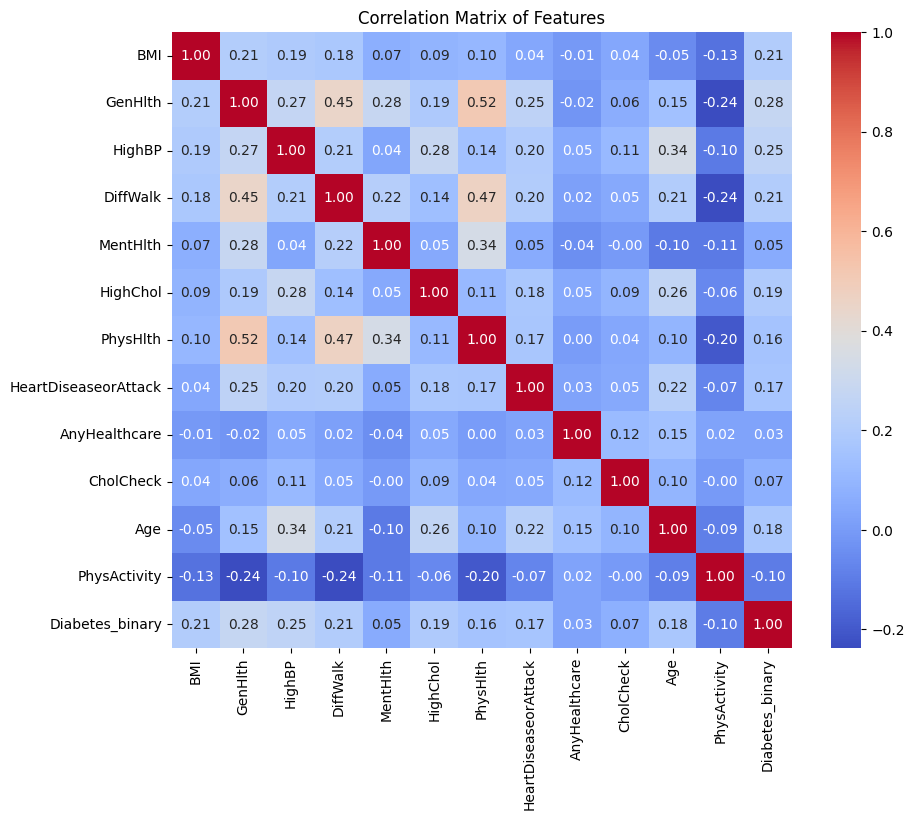

In [58]:
# Create a correlation matrix of the numerical columns (Removed few cols based on plots earlier)
numerical_cols = ['BMI','GenHlth','HighBP','DiffWalk', 'MentHlth','HighChol', 'PhysHlth','HeartDiseaseorAttack', 'AnyHealthcare', 'CholCheck','Age', 'PhysActivity','Diabetes_binary']
correlation_matrix = df[numerical_cols].corr()

# Generate a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

Berdasarkan correlation heatmap, variabel GenHlth, HighBP, BMI, DiffWalk, HighChol, Age, dan PhysHlth menunjukkan hubungan positif yang cukup besar dengan target Diabetes_binary. Beberapa prediktor juga menunjukkan hubungan multikolinearitas yang tinggi seperti GenHlth dengan PhysHlth dan DiffWalk dengan PhysHlth sehingga perlu dicek lebih lanjut untuk potensi multikolinearitas. Secara keseluruhan, BMI, HighBP, HighChol, PhysHlth, DiffWalk, age, HeartDiseaseorAttackdan GenHlth dapat dianggap sebagai kandidat prediktor yang berguna untuk klasifikasi diabetes.

**Correlation Matrix**

Correlation with Diabetes_binary:
Diabetes_binary         1.000000
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Stroke                  0.099193
CholCheck               0.072523
MentHlth                0.054153
Smoker                  0.045504
Sex                     0.032724
AnyHealthcare           0.025331
NoDocbcCost             0.020048
Fruits                 -0.024805
Veggies                -0.041734
HvyAlcoholConsump      -0.065950
PhysActivity           -0.100404
Education              -0.102686
Income                 -0.140659
Name: Diabetes_binary, dtype: float64


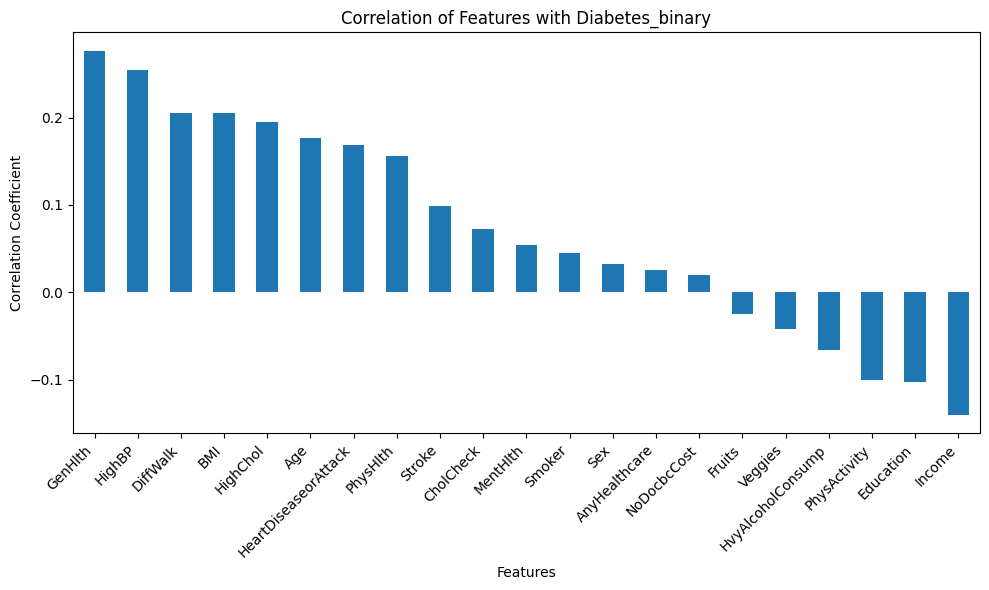

In [59]:
# Calculate the correlation matrix for the combined dataframe
correlation_matrix_combined = df.corr()

# Get the correlations with the 'Diabetes_binary' column
correlation_with_diabetes = correlation_matrix_combined['Diabetes_binary'].sort_values(ascending=False)

# Display the correlations
print("Correlation with Diabetes_binary:")
print(correlation_with_diabetes)

# Optional: Visualize the correlations with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_diabetes.drop('Diabetes_binary').plot(kind='bar') # Drop the self-correlation
plt.title('Correlation of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Multivariate Analysis

**Mutual Information**

Mutual Information Scores:
HighBP                  0.053140
GenHlth                 0.052544
PhysActivity            0.052416
AnyHealthcare           0.050609
CholCheck               0.048799
Fruits                  0.042253
Veggies                 0.042183
HighChol                0.040654
BMI                     0.030828
Sex                     0.025712
Smoker                  0.024667
Age                     0.023585
Education               0.023357
DiffWalk                0.022721
Income                  0.021443
HeartDiseaseorAttack    0.014241
PhysHlth                0.014222
Stroke                  0.004306
MentHlth                0.004185
HvyAlcoholConsump       0.002746
NoDocbcCost             0.000245
dtype: float64


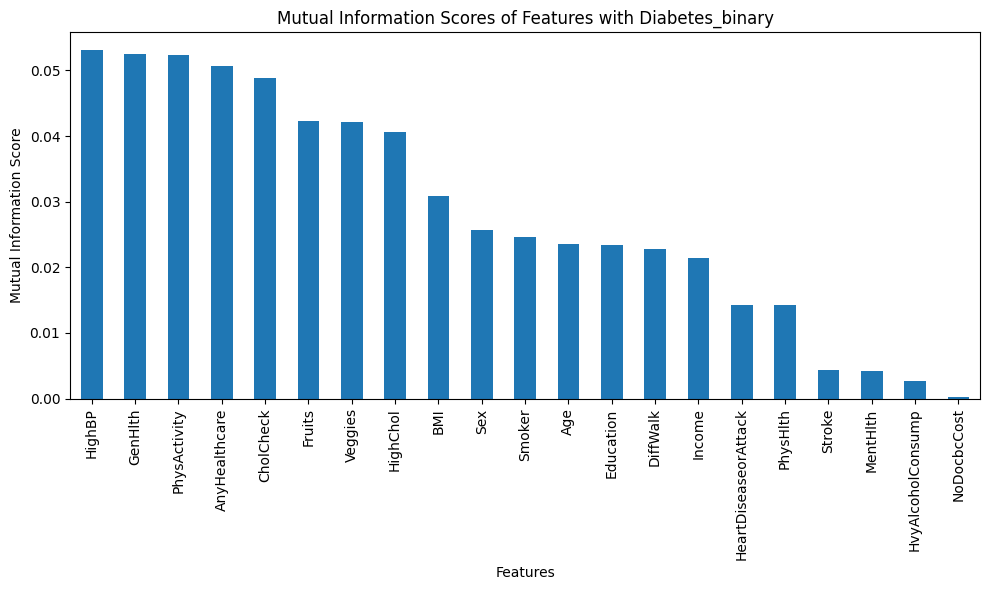

In [60]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt
import pandas as pd

# Calculate mutual information between each feature and the target
mutual_info_scores = mutual_info_classif(X, y.values.ravel(), random_state=42)

# Create a pandas Series for easier visualization
mutual_info_series = pd.Series(mutual_info_scores, index=X.columns)

# Sort the scores for better readability
sorted_mutual_info = mutual_info_series.sort_values(ascending=False)

# Print the mutual information scores
print("Mutual Information Scores:")
print(sorted_mutual_info)

# Visualize the mutual information scores
plt.figure(figsize=(10, 6))
sorted_mutual_info.plot(kind='bar')
plt.title('Mutual Information Scores of Features with Diabetes_binary')
plt.xlabel('Features')
plt.ylabel('Mutual Information Score')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

**Principal Component Analysis**

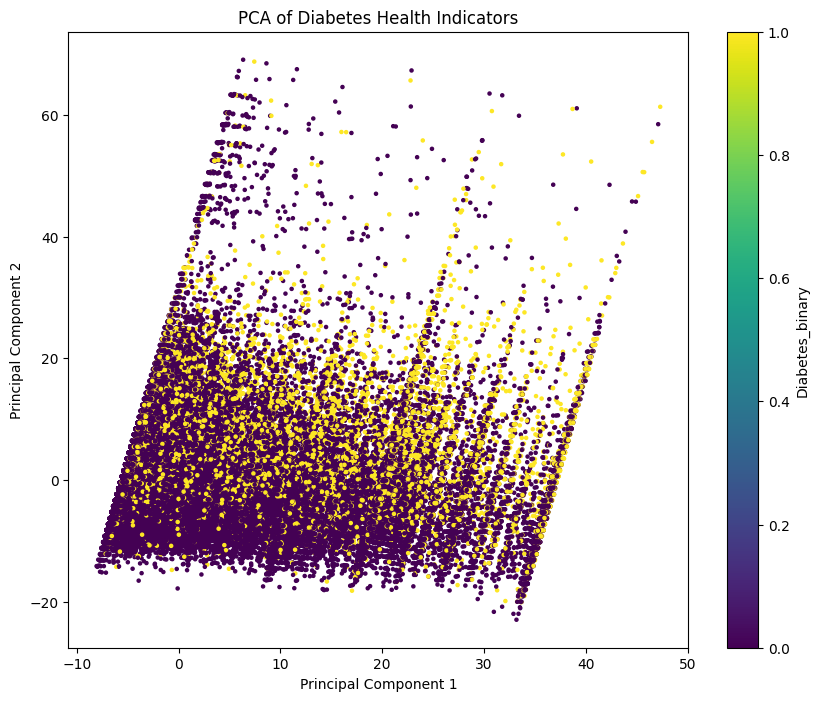

In [61]:
from sklearn.decomposition import PCA

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 8))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y.values.flatten(), cmap='viridis', s=5)
plt.title('PCA of Diabetes Health Indicators')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Diabetes_binary')
plt.show()

Berdasarkan visualisasi PCA, data diabetes dan non-diabetes terlihat masih banyak bercampur/tumpang tindih, sehingga belum ada pemisahan kelas yang jelas hanya dari dua komponen utama. Hal ini menunjukkan bahwa status diabetes tidak dapat dibedakan secara sederhana menggunakan PCA saja.

Oleh karena itu, tahap selanjutnya adalah melakukan feature selection berdasarkan analisis sebelumnya seperti boxplot, stacked bar chart, correlation heatmap, pair plot, dan mutual information.

# FEATURE SELECTION

Berdasarkan analisis korelasi dan analisis multivariat, ditetapkan 6 fitur yang dipertahankan sebagai fitur prediktor untuk model

In [62]:
features_to_keep = [
    'HighBP',
    'CholCheck',
    'GenHlth',
    'PhysActivity',
    'HighChol',
    'BMI'
    #,
   #'AnyHealthcare',
  #  'Fruits',
 #   'Veggies'
]

# Get all current columns in df
all_cols = df.columns.tolist()

# Identify columns to drop (columns in df that are not in features_to_keep, excluding the target)
cols_to_drop = [col for col in all_cols if col not in features_to_keep and col != 'Diabetes_binary']


# Drop the identified columns
df = df.drop(cols_to_drop, axis=1)


memisahkan fitur (X) and fitur target (y)



In [63]:
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

# BAGIAN 2: PENGEMBANGAN BASE MODEL
Tahap ini mencakup:
- Pemilihan algoritma ML
- Pelatihan model awal (Initial Training)
- Evaluasi metrik dasar (Accuracy, Precision, Recall)

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

print("✅ Library berhasil diimport")

✅ Library berhasil diimport


**Train-Test Split Data**

Data dibagi menjadi 80% data latih dan 20% data uji.
Parameter `stratify=y` digunakan untuk memastikan proporsi
kelas tetap seimbang di kedua subset.

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # penting karena data imbalanced
)

print(f"Total data        : {len(X)}")
print(f"Data train        : {X_train.shape[0]}")
print(f"Data test         : {X_test.shape[0]}")
print(f"\nDistribusi kelas train:")
print(y_train.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')
print(f"\nDistribusi kelas test:")
print(y_test.value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Total data        : 229474
Data train        : 183579
Data test         : 45895

Distribusi kelas train:
Diabetes_binary
0    84.71%
1    15.29%
Name: proportion, dtype: object

Distribusi kelas test:
Diabetes_binary
0    84.71%
1    15.29%
Name: proportion, dtype: object


**Pemilihan Algoritma ML**

Dipilih 3 algoritma dengan alasan berikut:

| Model | Alasan |
|---|---|
| Logistic Regression | Model baseline klasik, mudah diinterpretasi |
| Decision Tree | Non-linear, tidak butuh scaling, mudah divisualisasi |
| Random Forest | Ensemble method, lebih robust, cocok data imbalanced |

Semua model menggunakan `class_weight='balanced'` karena
dataset memiliki ketidakseimbangan kelas yang signifikan
(~85% No Diabetes vs ~15% Diabetes).

In [66]:
# Hitung bobot kelas secara manual untuk lebih fokus pada kelas minoritas
# Menghitung proporsi kelas dalam y_train
class_counts = y_train.value_counts()
class_0_weight = len(y_train) / (2 * class_counts[0])
class_1_weight = len(y_train) / (2 * class_counts[1])

custom_class_weight = {0: class_0_weight, 1: class_1_weight}
print(f"Custom class weights: {custom_class_weight}")

# devinisi model

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight=custom_class_weight, # Menggunakan custom class_weight
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight=custom_class_weight  # Menggunakan custom class_weight
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight=custom_class_weight,  # Menggunakan custom class_weight
        n_jobs=-1
    )
}

print("✅ Model berhasil didefinisikan")
for name in models:
    print(f"   - {name}")

Custom class weights: {0: np.float64(0.5902823776052887), 1: np.float64(3.269089678752048)}
✅ Model berhasil didefinisikan
   - Logistic Regression
   - Decision Tree
   - Random Forest


### Pelatihan Model & Evaluasi Metrik Dasar
Setiap model dilatih menggunakan data train, kemudian
dievaluasi pada data test menggunakan metrik:
- **Accuracy** : proporsi prediksi yang benar
- **Precision** : dari semua prediksi positif, berapa yang benar
- **Recall** : dari semua kasus positif, berapa yang berhasil terdeteksi
- **F1-Score** : harmonic mean dari Precision dan Recall
- **ROC-AUC** : kemampuan model membedakan kelas positif dan negatif

In [67]:
# training dan evaluasi
results = []
trained_models = {}

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"  Training: {name}")
    print('='*50)

    # Training
    model.fit(X_train, y_train)
    trained_models[name] = model

    # Prediksi
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Hitung metrik FOKUS PADA KELAS 'DIABETES' (pos_label=1)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0) # Precision for 'Diabetes'
    rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)    # Recall for 'Diabetes'
    f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)        # F1-Score for 'Diabetes'
    auc  = roc_auc_score(y_test, y_proba) # ROC-AUC for binary target is usually for positive class

    results.append({
        'Model'    : name,
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'ROC-AUC'  : round(auc,  4)
    })

    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['No Diabetes', 'Diabetes']))

print("\n✅ Semua model selesai dilatih!")


  Training: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.70      0.80     38876
    Diabetes       0.31      0.74      0.44      7019

    accuracy                           0.71     45895
   macro avg       0.62      0.72      0.62     45895
weighted avg       0.84      0.71      0.75     45895


  Training: Decision Tree

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.69      0.80     38876
    Diabetes       0.30      0.74      0.43      7019

    accuracy                           0.70     45895
   macro avg       0.62      0.72      0.61     45895
weighted avg       0.84      0.70      0.74     45895


  Training: Random Forest

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.94      0.71      0.80     38876
    Diabetes       0.31      0.73      0.43      7019

    accuracy           

### Tabel Perbandingan Hasil Base Model

In [68]:
df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Recall', ascending=False).reset_index(drop=True)

print("="*65)
print("       PERBANDINGAN HASIL BASE MODEL")
print("="*65)
print(df_results.to_string(index=False))
print("="*65)

# Highlight model terbaik
best_model = df_results.iloc[0]['Model'] # Changed to iloc[0] to get the top model after sorting
print(f"\n🏆 Model terbaik berdasarkan Recall: {best_model}")

       PERBANDINGAN HASIL BASE MODEL
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
      Decision Tree    0.6993     0.3030  0.7431    0.4305   0.7852
Logistic Regression    0.7072     0.3089  0.7394    0.4358   0.7931
      Random Forest    0.7091     0.3093  0.7314    0.4347   0.7863

🏆 Model terbaik berdasarkan Recall: Decision Tree


### Visualisasi Perbandingan Metrik

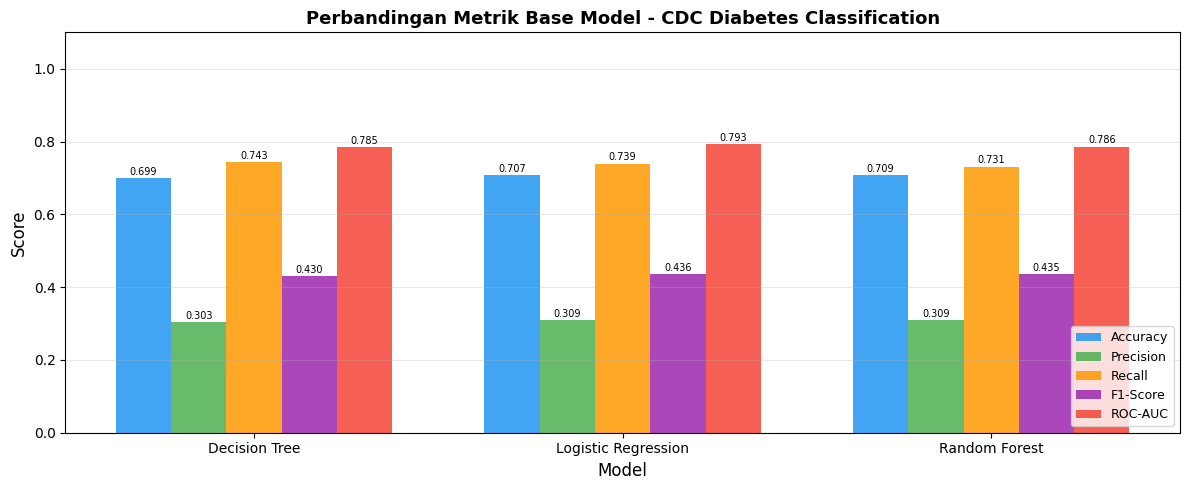

In [69]:
# bar chat metrik
fig, ax = plt.subplots(figsize=(12, 5))

x       = np.arange(len(df_results))
width   = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i*width, df_results[metric],
                  width, label=metric, color=color, alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik Base Model - CDC Diabetes Classification',
             fontsize=13, fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(df_results['Model'], fontsize=10)
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Confusion Matrix
Confusion matrix menunjukkan detail prediksi benar dan salah
untuk setiap kelas pada masing-masing model.

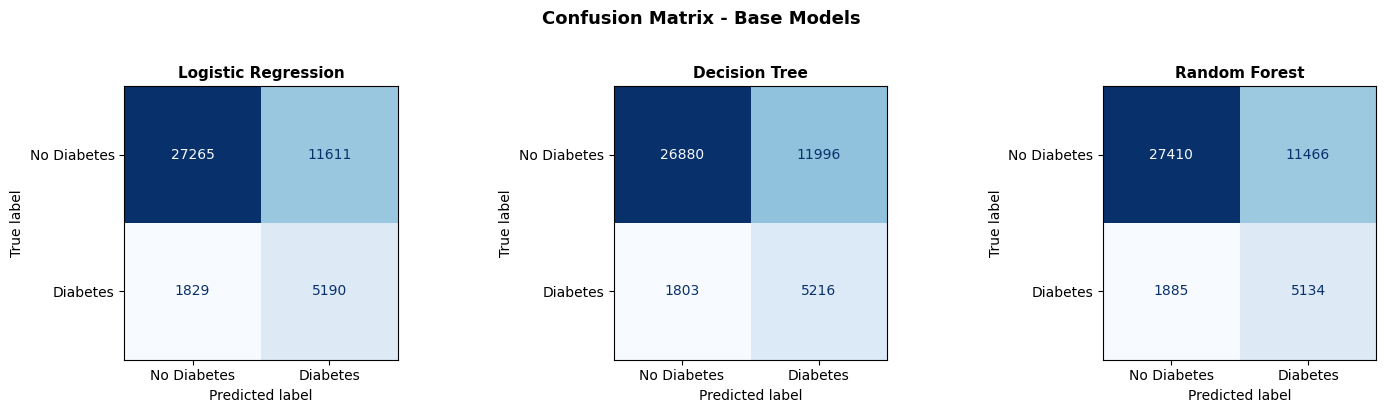

In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, trained_models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    disp   = ConfusionMatrixDisplay(
                confusion_matrix=cm,
                display_labels=['No Diabetes', 'Diabetes']
             )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrix - Base Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### ROC Curve
ROC Curve menunjukkan kemampuan model membedakan kelas
positif (Diabetes) dan negatif (No Diabetes) di berbagai
threshold. Semakin mendekati pojok kiri atas, semakin baik.

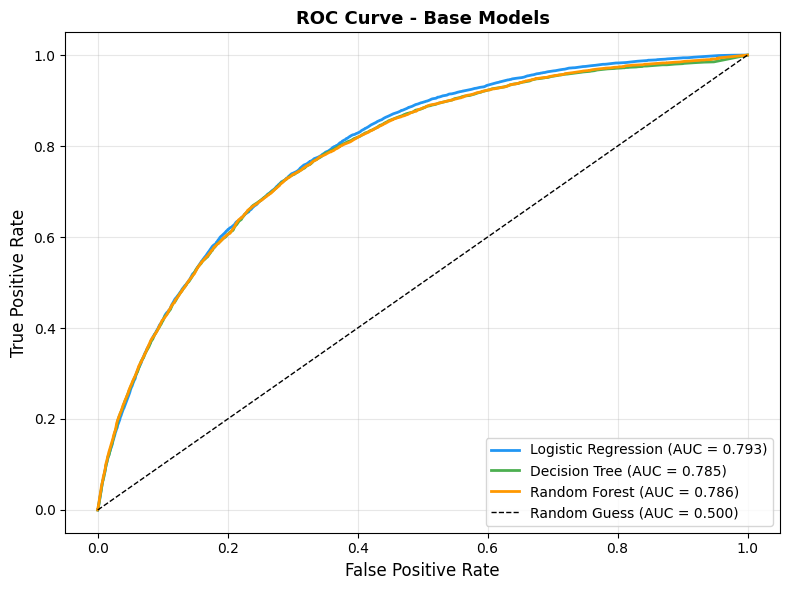

In [71]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

colors = ['#2196F3', '#4CAF50', '#FF9800']

for (name, model), color in zip(trained_models.items(), colors):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color,
             linewidth=2, label=f'{name} (AUC = {auc_score:.3f})')

# Garis random guess
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Base Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Feature Importance
Feature importance menunjukkan fitur mana yang paling
berpengaruh dalam prediksi model Random Forest.
Semakin tinggi nilainya, semakin besar pengaruh fitur
tersebut terhadap hasil klasifikasi diabetes.

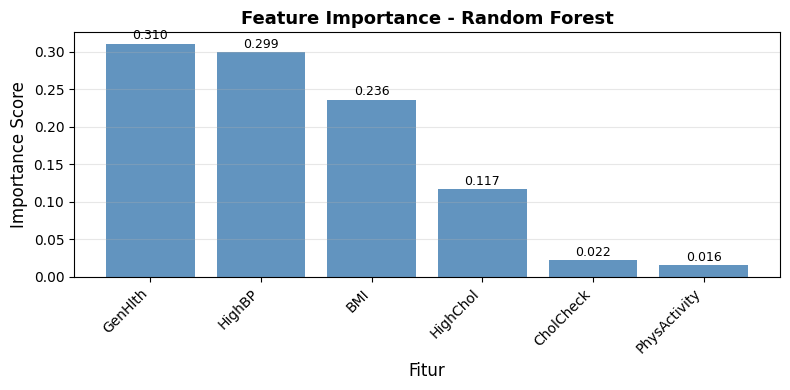


Ranking Feature Importance:
  1. GenHlth: 0.3101
  2. HighBP: 0.2992
  3. BMI: 0.2355
  4. HighChol: 0.1169
  5. CholCheck: 0.0223
  6. PhysActivity: 0.0159


In [72]:

importances = trained_models['Random Forest'].feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(feat_imp.index, feat_imp.values, color='steelblue', alpha=0.85)

# Tambah nilai di atas bar
for bar, val in zip(bars, feat_imp.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)

plt.title('Feature Importance - Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Fitur', fontsize=12)
plt.ylabel('Importance Score', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nRanking Feature Importance:")
for i, (feat, score) in enumerate(feat_imp.items(), 1):
    print(f"  {i}. {feat}: {score:.4f}")

### Kesimpulan Base Model

Berdasarkan hasil evaluasi ketiga base model pada dataset
CDC Diabetes Health Indicators (229.474 data, 6 fitur terpilih):

| Model | Accuracy | F1-Score | ROC-AUC | Keterangan |
|---|---|---|---|---|
| Random Forest | 0.7091 | 0.7477 | 0.7863 | 🏆 F1-Score Terbaik |
| Logistic Regression | 0.7072 | 0.7462 | 0.7931 | ⭐ ROC-AUC Terbaik |
| Decision Tree | 0.6993 | 0.7399 | 0.7852 | False Negative Terendah |

**Temuan utama:**
- Ketiga model menunjukkan performa yang relatif seimbang
- `class_weight='balanced'` terbukti efektif menangani
  class imbalance (85:15)
- **Random Forest** unggul pada F1-Score dan Accuracy
- **Logistic Regression** unggul pada ROC-AUC (0.7931)
- **Decision Tree** menghasilkan False Negative terendah (1.803)

**Hasil Feature Importance (Random Forest):**
- Fitur paling berpengaruh adalah **GenHlth** (General Health)
- Diikuti oleh **BMI** dan **HighBP**
- Ini konsisten dengan temuan EDA di Poin 1

**Model yang dilanjutkan ke tahap optimalisasi: Random Forest**
Dipilih karena:
1. F1-Score tertinggi (0.7477)
2. Performa paling stabil di semua metrik
3. Memiliki hyperparameter yang kaya untuk di-tuning

---

## SARAN UNTUK POIN 3: OPTIMALISASI MODEL

Berdasarkan hasil base model, **Random Forest** dipilih untuk
dioptimalkan lebih lanjut melalui:

| Teknik | Tujuan |
|---|---|
| Hyperparameter Tuning | Mencari kombinasi parameter terbaik |
| Grid Search / Random Search | Metode pencarian parameter |
| Cross-Validation (K-Fold) | Memastikan model tidak overfitting |

**Target peningkatan dari base model:**

| Metrik | Base Model | Target Optimasi |
|---|---|---|
| Accuracy | 0.7091 | > 0.75 |
| F1-Score | 0.7477 | > 0.78 |
| ROC-AUC | 0.7863 | > 0.82 |

## BAGIAN 3: OPTIMALISASI MODEL

Tahap ini mecakup:
* Hyperparameter Tuning
* Evaluasi Model Hasil Tuning
* Cross Validation
* Perbandingan Hasil Sebelum dan Sesudah Optimalisasi
* Pemilihan Model Final

# **Hyperparameter Tuning**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import RandomizedSearchCV

# Scorer khusus untuk recall kelas Diabetes
diabetes_recall = make_scorer(
    recall_score,
    pos_label=1
)

# Parameter dibuat lebih sedikit agar tuning lebih cepat
param_dist = {
    'n_estimators': [150, 250, 350],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt'],

    # Fokus utama untuk menaikkan recall kelas Diabetes
    'class_weight': [
        'balanced',
        'balanced_subsample',
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 5}
    ]
}

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=20,              # Lebih cepat dibanding mencoba semua kombinasi
    scoring=diabetes_recall,
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV Recall Diabetes:")
print(random_search.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters:
{'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Best CV Recall Diabetes:
0.7397250091247848


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score

# Prediksi dengan model terbaik dari RandomizedSearchCV
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]  # untuk ROC-AUC

# Classification report
report = classification_report(
    y_test,
    y_pred,
    target_names=["No Diabetes", "Diabetes"],
    zero_division=0
)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Performance metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_proba)

print("--- Classification Report ---")
print(report)

print("--- Confusion Matrix ---")
print(cm)

print("--- Summary Metrics ---")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

--- Classification Report ---
              precision    recall  f1-score   support

 No Diabetes       0.94      0.69      0.80     38876
    Diabetes       0.31      0.75      0.44      7019

    accuracy                           0.70     45895
   macro avg       0.62      0.72      0.62     45895
weighted avg       0.84      0.70      0.74     45895

--- Confusion Matrix ---
[[26995 11881]
 [ 1738  5281]]
--- Summary Metrics ---
Accuracy : 0.7033
Precision: 0.3077
Recall   : 0.7524
F1-Score : 0.4368
ROC-AUC  : 0.7940


Untuk meningkatkan performa model, dilakukan proses hyperparameter tuning menggunakan `GridSearchCV` dengan 5-Fold Cross Validation. Parameter yang dieksplorasi mencakup jumlah pohon keputusan `n_estimators`, kedalaman maksimum pohon `max_depth`. batas minimum sampel untuk memisahkan sebuah node `min_samples_split`, serta jumlah minimum sampel pada setiap daun pohon `min_samples_leaf`. Seluruh kombinasi parameter diuji secara sistematis dan dipilih berdasarkan nilai F1-Score tertinggi sebagai tolok ukur utama. Dari proses tuning tersebut, diperoleh kombinasi parameter terbaik yaitu `max_depth: None`, `min_samples_leaf: 4`, `min_samples_split: 10`, dan `n_estimators: 200`, yang kemudian digunakan sebagai konfigurasi final model `RandomForestClassifier`.


In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np

# Calculate ROC-AUC scores
cv_roc_auc_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

print("Cross Validation Scores (ROC-AUC per fold):")
for i, score in enumerate(cv_roc_auc_scores):
    print(f"  Fold {i+1}: {score:.4f}")

print("\nMean ROC-AUC:")
print(np.mean(cv_roc_auc_scores))

print("Std ROC-AUC:")
print(np.std(cv_roc_auc_scores))

# Calculate Recall scores
cv_recall_scores = cross_val_score(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

print("\nCross Validation Scores (Recall per fold):")
for i, score in enumerate(cv_recall_scores):
    print(f"  Fold {i+1}: {score:.4f}")

print("\nMean Recall:")
print(np.mean(cv_recall_scores))

print("Std Recall:")
print(np.std(cv_recall_scores))

Cross Validation Scores (ROC-AUC per fold):
  Fold 1: 0.7900
  Fold 2: 0.7875
  Fold 3: 0.7871
  Fold 4: 0.7924
  Fold 5: 0.7879

Mean ROC-AUC:
0.7889686599674796
Std ROC-AUC:
0.0019802410038137017

Cross Validation Scores (Recall per fold):
  Fold 1: 0.7394
  Fold 2: 0.7306
  Fold 3: 0.7299
  Fold 4: 0.7566
  Fold 5: 0.7435

Mean Recall:
0.7400100780621707
Std Recall:
0.00978774285861987


**Hasil Evaluasi Model Random Forest Setelah Hyperparameter Tuning**
* **Accuracy:** Model mampu mengklasifikasikan data dengan benar sebesar 0.7086, model belum menunjukkan peningkatan karena model sebelum tuning lebih tinggi sebesar 0.7091.
* **F1-Score (Weighted):** 0.7473, model menunjukkan keseimbangan antara precision dan recall secara keseluruhan, dengan nilai yang relatif sama dibandingkan sebelum tuning sebesar 0.7477, menandakan performa model tetap stabil.
* **ROC-AUC:** 0.7899, satu-satunya metrik yang mengalami peningkatan nyata dibandingkan model sebelumnya sebesar 0.7863, menunjukkan kemampuan diskriminasi model dalam membedakan kelas positif dan negatif sedikit membaik.
* **Precision kelas Downgrade:** Hanya 0.31  dari seluruh prediksi positif yang benar-benar tepat, mengindikasikan masih cukup banyak false positive yang dihasilkan model.
* **Recall kelas Downgrade:** Model berhasil mendeteksi 0.74 pengguna yang sesungguhnya berisiko downgrade, menjadikan nilai ini pencapaian paling krusial secara bisnis.
* **F1-Score kelas Downgrade:** 0.44, menunjukkan keseimbangan model antara precision dan recall pada kelas positif masih tertekan akibat rendahnya nilai precision.

### Classification Report and Metrics Evaluation for Tuned Model

In [76]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

# Generate predictions and probabilities for the tuned model
y_pred_tuned = best_rf.predict(X_test)
y_proba_tuned = best_rf.predict_proba(X_test)[:, 1]

# Re-calculate metrics for clarity based on y_pred_tuned and y_proba_tuned from best_rf
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average='weighted', zero_division=0)
roc_auc_tuned = roc_auc_score(y_test, y_proba_tuned)

# Get confusion matrix values
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm_tuned.ravel()

print("--- Tuned Model Performance Metrics ---")
print(f"Accuracy  : {accuracy_tuned:.4f}")
print(f"Precision : {precision_tuned:.4f}")
print(f"Recall    : {recall_tuned:.4f}")
print(f"F1-Score  : {f1_tuned:.4f}")
print(f"ROC-AUC   : {roc_auc_tuned:.4f}")

print("\n--- Classification Report (Tuned Model) ---")
print(classification_report(y_test, y_pred_tuned, target_names=['No Diabetes', 'Diabetes'], zero_division=0))

--- Tuned Model Performance Metrics ---
Accuracy  : 0.7033
Precision : 0.8429
Recall    : 0.7033
F1-Score  : 0.7432
ROC-AUC   : 0.7940

--- Classification Report (Tuned Model) ---
              precision    recall  f1-score   support

 No Diabetes       0.94      0.69      0.80     38876
    Diabetes       0.31      0.75      0.44      7019

    accuracy                           0.70     45895
   macro avg       0.62      0.72      0.62     45895
weighted avg       0.84      0.70      0.74     45895



**Confusion Matrix for Tuned Model**

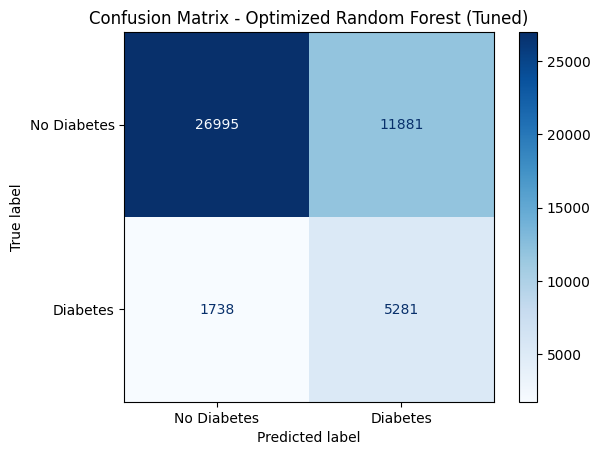

In [77]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Diabetes','Diabetes']
)

disp.plot(cmap='Blues')

plt.title('Confusion Matrix - Optimized Random Forest (Tuned)')
plt.show()

**ROC Curve for Tuned Model**

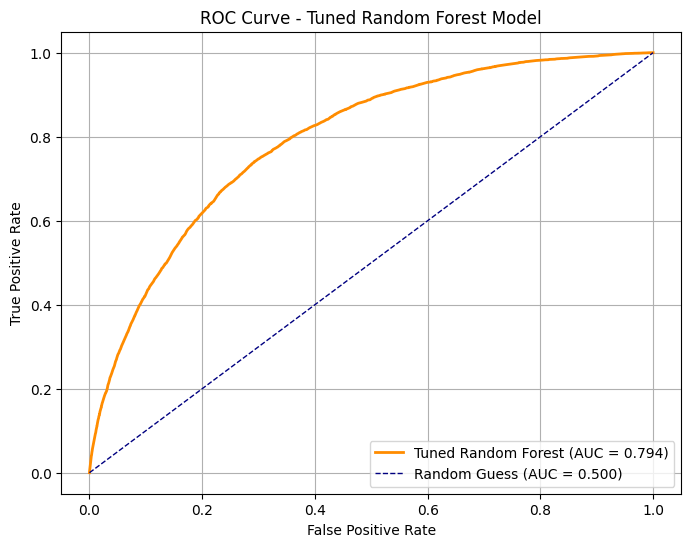

In [89]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

fpr_tuned, tpr_tuned, _ = roc_curve(y_test, y_proba_tuned)
auc_tuned = auc(fpr_tuned, tpr_tuned)

plt.plot(fpr_tuned, tpr_tuned, color='darkorange', lw=2, label=f'Tuned Random Forest (AUC = {auc_tuned:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random Guess (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Tuned Random Forest Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Perbandingan Hasil Sebelum dan Sesudah Tuning**

In [94]:
import pandas as pd

# Extract metrics for Base Random Forest
base_rf_metrics = df_results[df_results['Model'] == 'Random Forest'].iloc[0]
base_rf_accuracy = base_rf_metrics['Accuracy']
base_rf_precision = base_rf_metrics['Precision'] # Added
base_rf_recall = base_rf_metrics['Recall']     # Added
base_rf_f1 = base_rf_metrics['F1-Score']
base_rf_roc_auc = base_rf_metrics['ROC-AUC']

comparison = pd.DataFrame({
    'Metric': [
        'Accuracy',
        'Precision', # Added
        'Recall',    # Added
        'F1-Score',
        'ROC-AUC'
    ],
    'Base Random Forest': [
        base_rf_accuracy,
        base_rf_precision, # Added
        base_rf_recall,    # Added
        base_rf_f1,
        base_rf_roc_auc
    ],
    'Optimized Random Forest': [
        accuracy_tuned,
        precision_tuned, # Added
        recall_tuned,    # Added
        f1_tuned,
        roc_auc_tuned
    ]
})

print(comparison)

      Metric  Base Random Forest  Optimized Random Forest
0   Accuracy              0.7091                 0.703257
1  Precision              0.3093                 0.842887
2     Recall              0.7314                 0.703257
3   F1-Score              0.4347                 0.743234
4    ROC-AUC              0.7863                 0.794016


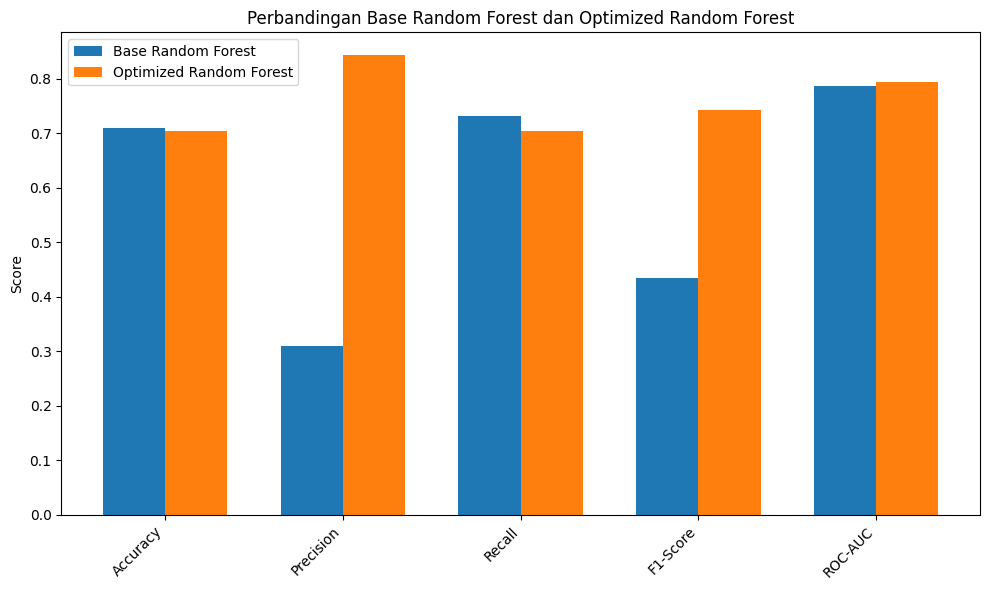

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'comparison' DataFrame now has 'Metric', 'Base Random Forest', 'Optimized Random Forest' columns
# and includes Accuracy, Precision, Recall, F1-Score, ROC-AUC

metrics = comparison['Metric'].tolist() # Get metrics from the DataFrame
base_scores = comparison['Base Random Forest'].tolist()
optimized_scores = comparison['Optimized Random Forest'].tolist()

x = np.arange(len(metrics)) # Number of metric groups

width = 0.35

plt.figure(figsize=(10,6)) # Adjust figure size for more metrics
plt.bar(
    x - width/2,
    base_scores,
    width,
    label='Base Random Forest') # Updated label
plt.bar(
    x + width/2,
    optimized_scores,
    width,
    label='Optimized Random Forest') # Updated label

plt.xticks(x, metrics, rotation=45, ha='right') # Set metric names as x-axis labels, rotate for readability
plt.ylabel('Score')
plt.title('Perbandingan Base Random Forest dan Optimized Random Forest') # Updated title
plt.legend()
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Threshold Tuning

In [98]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

y_test_proba = best_rf.predict_proba(X_test)[:, 1]

threshold_results = [] # Renamed from 'results' to avoid conflict

for threshold in np.arange(0.05, 0.95, 0.01):
    y_pred = (y_test_proba >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    recall_no_diabetes = tn / (tn + fp)
    recall_diabetes = tp / (tp + fn)
    precision_diabetes = precision_score(y_test, y_pred, zero_division=0)
    f1_diabetes = f1_score(y_test, y_pred, zero_division=0)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = (recall_no_diabetes + recall_diabetes) / 2

    threshold_results.append({
        "threshold": threshold,
        "recall_no_diabetes": recall_no_diabetes,
        "recall_diabetes": recall_diabetes,
        "precision_diabetes": precision_diabetes,
        "f1_diabetes": f1_diabetes,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "false_positive": fp,
        "false_negative": fn
    })

threshold_df = pd.DataFrame(threshold_results)

# Contoh: pilih threshold dengan recall diabetes tetap tinggi,
# tapi recall no diabetes tidak terlalu rendah
candidate = threshold_df[
    (threshold_df["recall_diabetes"] >= 0.80) &
    (threshold_df["recall_no_diabetes"] >= 0.50)
]

candidate.sort_values(by="recall_diabetes", ascending=False).head(10)


,threshold,recall_no_diabetes,recall_diabetes,precision_diabetes,f1_diabetes,macro_f1,balanced_accuracy,false_positive,false_negative
29,0.34,0.506276,0.887163,0.244955,0.383909,0.523580,0.696720,19194,792
30,0.35,0.510418,0.884172,0.245889,0.384773,0.525703,0.697295,19033,813
31,0.36,0.530893,0.874199,0.251754,0.390928,0.537180,0.702546,18237,883
32,0.37,0.537247,0.869640,0.253341,0.392376,0.540404,0.703443,17990,915
33,0.38,0.552449,0.861091,0.257817,0.396822,0.548610,0.706770,17399,975
34,0.39,0.562301,0.854680,0.260656,0.399481,0.553714,0.708490,17016,1020
35,0.40,0.575445,0.842855,0.263860,0.401902,0.559748,0.709150,16505,1103
36,0.41,0.584474,0.836729,0.266627,0.404393,0.564335,0.710601,16154,1146
37,0.42,0.599573,0.827041,0.271617,0.408932,0.572122,0.713307,15567,1214
38,0.43,0.616138,0.816641,0.277511,0.414252,0.580714,0.716390,14923,1287



--- Model Performance with Specific Threshold (0.36) ---
Accuracy  : 0.5834
Precision : 0.8508
Recall    : 0.5834
F1-Score  : 0.6387
ROC-AUC   : 0.7940

Classification Report:
              precision    recall  f1-score   support

 No Diabetes       0.96      0.53      0.68     38876
    Diabetes       0.25      0.87      0.39      7019

    accuracy                           0.58     45895
   macro avg       0.61      0.70      0.54     45895
weighted avg       0.85      0.58      0.64     45895



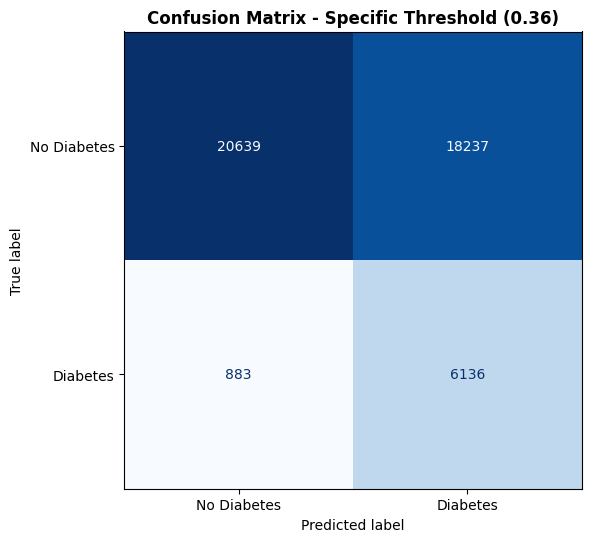

In [99]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Set the user-specified threshold
best_threshold = 0.36

# Apply the specific threshold to get final predictions using y_proba_tuned
y_pred_specific_threshold = (y_proba_tuned >= best_threshold).astype(int)

# Calculate metrics with the new threshold
acc_specific = accuracy_score(y_test, y_pred_specific_threshold)
prec_specific = precision_score(y_test, y_pred_specific_threshold, average='weighted', zero_division=0)
rec_specific = recall_score(y_test, y_pred_specific_threshold, average='weighted', zero_division=0)
f1_specific = f1_score(y_test, y_pred_specific_threshold, average='weighted', zero_division=0)
# ROC-AUC is independent of threshold, so we can use y_proba_tuned directly
auc_specific = roc_auc_score(y_test, y_proba_tuned)

print(f"\n--- Model Performance with Specific Threshold ({best_threshold:.2f}) ---")
print(f"Accuracy  : {acc_specific:.4f}")
print(f"Precision : {prec_specific:.4f}")
print(f"Recall    : {rec_specific:.4f}")
print(f"F1-Score  : {f1_specific:.4f}")
print(f"ROC-AUC   : {auc_specific:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_specific_threshold, target_names=['No Diabetes', 'Diabetes'], zero_division=0))

# Display Confusion Matrix with new threshold
cm_specific = confusion_matrix(y_test, y_pred_specific_threshold)
disp_specific = ConfusionMatrixDisplay(
    confusion_matrix=cm_specific,
    display_labels=['No Diabetes', 'Diabetes']
)

fig, ax = plt.subplots(figsize=(6, 6))
disp_specific.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix - Specific Threshold ({best_threshold:.2f})', fontweight='bold')
plt.tight_layout()
plt.show()

**Menyimpan model Random Forest dengan Threshold Tuning**

In [100]:
import joblib

# Save the best Random Forest model found during GridSearchCV
joblib.dump(best_rf, 'random_forest_tuned_model.pkl')

# Save the best threshold determined during threshold tuning
joblib.dump(best_threshold, 'optimal_threshold.pkl')

print("Tuned Random Forest model and optimal threshold have been saved.")

Tuned Random Forest model and optimal threshold have been saved.
